In [16]:
import pandas as pd

In [17]:
#pip install git+https://github.com/quantopian/pyfolio
# import again if first time not work
import pyfolio

In [18]:
import matplotlib
matplotlib.use('Agg')
%matplotlib inline

In [19]:
def get_daily_return(df):
    df['daily_return']=df.account_value.pct_change(1)
    #df=df.dropna()
    print('Sharpe: ',(252**0.5)*df['daily_return'].mean()/ df['daily_return'].std())
    return df

In [20]:
def backtest_strat(df):
    strategy_ret= df.copy()
    strategy_ret['Date'] = pd.to_datetime(strategy_ret['Date'])
    strategy_ret.set_index('Date', drop = False, inplace = True)
    strategy_ret.index = strategy_ret.index.tz_localize('UTC')
    del strategy_ret['Date']
    ts = pd.Series(strategy_ret['daily_return'].values, index=strategy_ret.index)
    return ts

In [21]:
def get_account_value(model_name):
    df_account_value=pd.DataFrame()
    for i in range(rebalance_window+validation_window, len(unique_trade_date)+1,rebalance_window):
        temp = pd.read_csv('results/firstRun/account_value_trade_{}_{}.csv'.format(model_name,i))
        df_account_value = df_account_value.append(temp,ignore_index=True)
    df_account_value = pd.DataFrame({'account_value':df_account_value['0']})
    sharpe=(252**0.5)*df_account_value.account_value.pct_change(1).mean()/df_account_value.account_value.pct_change(1).std()
    print(sharpe)
    df_account_value=df_account_value.join(df_trade_date[63:].reset_index(drop=True))
    return df_account_value

## DJIA

In [22]:
dji = pd.read_csv("data/cleaned_^DJI_20130102_20240819.csv")
test_dji=dji[(dji['Date']>='2016-01-01') & (dji['Date']<='2020-06-30')]
test_dji = test_dji.reset_index(drop=True)

In [23]:
test_dji.shape

(1131, 7)

In [24]:
test_dji.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2016-01-04,17405.48,17405.48,16957.63,17148.94,17148.94,148060000
1,2016-01-05,17147.50,17195.84,17038.61,17158.66,17158.66,105750000
2,2016-01-06,17154.83,17154.83,16817.62,16906.51,16906.51,120250000
3,2016-01-07,16888.36,16888.36,16463.63,16514.10,16514.10,176240000
4,2016-01-08,16519.17,16651.89,16314.57,16346.45,16346.45,141850000


In [25]:
test_dji['daily_return']=test_dji['Adj Close'].pct_change(1)

In [26]:
dow_strat = backtest_strat(test_dji)

## Ensemble Strategy

In [27]:
df=pd.read_csv('data/cleaned_dow_30_2013_2024.csv')

In [28]:
rebalance_window = 63
validation_window = 63
unique_trade_date = df[(df.datadate > 20151001)&(df.datadate <= 20200707)].datadate.unique()


In [29]:
df_trade_date = pd.DataFrame({'datadate':unique_trade_date})

In [30]:
ensemble_account_value = get_account_value('ensemble')

1.5161118660149853


<AxesSubplot:>

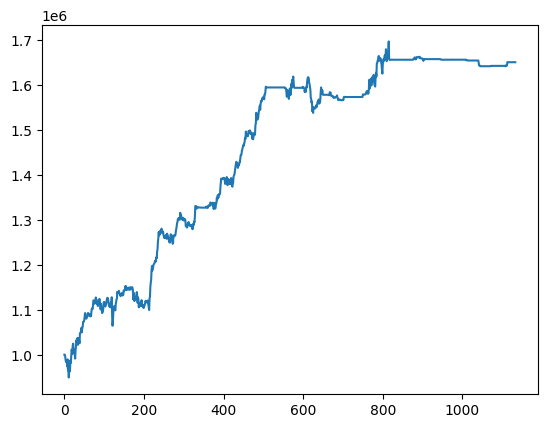

In [31]:
ensemble_account_value.account_value.plot()

In [32]:
ensemble_account_value = get_daily_return(ensemble_account_value)

Sharpe:  1.5161118660149853


In [33]:
ensemble_account_value['Date'] = test_dji['Date']

In [34]:
ensemble_account_value.head()

,account_value,datadate,daily_return,Date
0,1.000000e+06,20160104,NaN,2016-01-04
1,1.000096e+06,20160105,0.000096,2016-01-05
2,9.963688e+05,20160106,-0.003727,2016-01-06
3,9.883389e+05,20160107,-0.008059,2016-01-07
4,9.844544e+05,20160108,-0.003930,2016-01-08


In [35]:
ensemble_strat = backtest_strat(ensemble_account_value[0:1097])
#new adding
print(type(ensemble_strat))
print(type(ensemble_strat.index))
print(ensemble_strat.index[:5])

<class 'pandas.core.series.Series'>
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['2016-01-04 00:00:00+00:00', '2016-01-05 00:00:00+00:00',
               '2016-01-06 00:00:00+00:00', '2016-01-07 00:00:00+00:00',
               '2016-01-08 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Date', freq=None)


In [36]:
#ensemble_account_value.to_csv('results/df_account_value_ensemble_daily_return.csv',index=False)

In [37]:
with pyfolio.plotting.plotting_context(font_scale=1.1):
    pyfolio.create_full_tear_sheet(returns = ensemble_strat,
                                   benchmark_rets=dow_strat, set_context=False)

Start date,2016-01-04
End date,2020-05-12
Total months,52
,Backtest
Annual return,12.1%
Cumulative returns,64.3%
Annual volatility,7.7%
Sharpe ratio,1.53
Calmar ratio,2.15
Stability,0.85
Max drawdown,-5.6%


AttributeError: 'numpy.int64' object has no attribute 'to_pydatetime'